In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA

import numpy as np
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pickle
import torch
import torchio as tio
import scipy.stats
import csv
import pandas as pd


## Analysis

In [11]:
pearsons_rs = pd.read_csv("./save_pearsons_r.csv")
pearsons_rs.keys()

Index(['data_type', 'elastic_transf_type', 'num_aug', 'num_comp', 'gm_r',
       'wm_r', 'csf_r'],
      dtype='object')

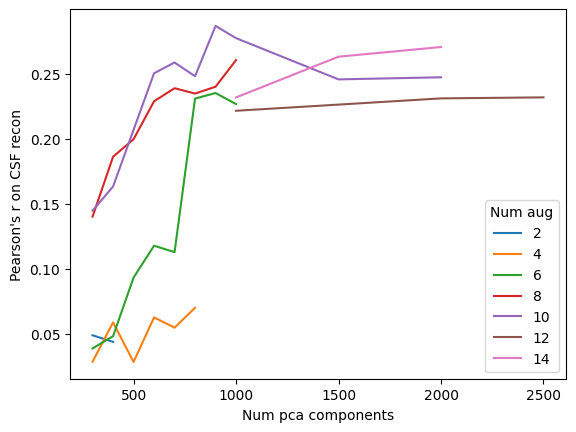

In [18]:
plt.figure()
labels = []

for i in [2,4,6,8,10,12,14]:
    plt.plot(pearsons_rs['num_comp'][pearsons_rs['num_aug'] == i], pearsons_rs['csf_r'][pearsons_rs['num_aug'] == i])
    labels.append(str(i))

plt.xlabel("Num pca components")
plt.ylabel("Pearson's r on CSF recon")
plt.legend(labels, title="Num aug")
plt.title("")
plt.show()

In [21]:
print(np.arange(2000, 4620, 500))

[2000 2500 3000 3500 4000 4500]


## Used for testing before putting in a script

In [6]:
# 1. load non augmented data
data_type = "human"

#####

def load_imgs(folder_path):
    images = []
    file_names = []

    for file_name in os.listdir(folder_path):
        img = sitk.ReadImage(folder_path + file_name)
        img_array = sitk.GetArrayFromImage(img)  # Normalize to [0, 1]
        images.append(img_array)

        file_names.append(file_name)

    # Convert to NumPy array: shape (n_images, height, width)
    images = np.stack(images)
    
    return images, file_names






In [ ]:
folder_path = "../../../3D-CycleGan-Pytorch-MedImaging/data/"

if data_type == "mouse":
    train_imgs, _ = load_imgs(folder_path + "train/images/") # mouse
    test_imgs, _ = load_imgs(folder_path + "test/images/")
else:
    train_imgs, _ = load_imgs(folder_path + "train/labels/") # human
    test_imgs, _ = load_imgs(folder_path + "test/labels/")

In [3]:
print(train_imgs.shape)

(240, 128, 120, 120)


In [ ]:
train_imgs_aug = np.load("/media/data/matter_masks_augs/human_augs_6.npy") # just 10 aug, I have done larger!!
aug_list = [train_imgs_aug]

# takes ~2min 30s to load

In [10]:
# 2. Augment the data

elastic_transf_type = "a"
num_aug = 6

#####
#train_imgs_aug = train_imgs

# Define transform
if elastic_transf_type == "a":
    num_control_points = 7
    max_displacement = 4.0
    locked_borders = 2

else:
    num_control_points = 5
    max_displacement = 2.0
    locked_borders = 5

elastic_transform = tio.RandomElasticDeformation(
    num_control_points=num_control_points,  # grid resolution, higher = more local warping
    max_displacement=max_displacement,  # max displacement in mm or voxels
    locked_borders=locked_borders,      # keep border fixed (avoid artifacts)
    image_interpolation='nearest'  # preserve label integrity
)

this_step_aug = []
for img in train_imgs:
    tensor = torch.from_numpy(img).unsqueeze(0).float()
    subject = tio.Subject(mask=tio.LabelMap(tensor=tensor))

    for i in range(2):
        non_lin_transformed = elastic_transform(subject)
        non_lin_transformed = non_lin_transformed['mask'].data.squeeze(0).numpy()
        this_step_aug.append(non_lin_transformed[None, ...])  # keep dims

print("transf complete, now concat")
# Combine new aug with old ones
aug_list.append(np.concatenate(this_step_aug, axis=0))
train_imgs_aug = np.concatenate(aug_list, axis=0)

# takes ~1min 30s to concat to 6 augs or 3 min to 8 augs

transf complete, now concat


In [11]:
print(train_imgs_aug.shape)
np.save("./" + data_type + "_augs_" + str(num_aug) +".npy", train_imgs_aug) # overwrites if already exists
# takes ~2min 30s in media or 20s locally for 6 or 1min 20s for 8


(1680, 128, 120, 120)


In [2]:
data_type = "human"
num_aug = 4
train_imgs_aug = np.load("./" + data_type + "_augs_" + str(num_aug) +".npy") # just 10 aug, I have done larger!!
#aug_list = [train_imgs_aug]

# takes ~ 5min to load from media for 4 aug or 40s to load 10 locally

In [3]:
print(train_imgs_aug.shape)

(1200, 128, 120, 120)


In [3]:
# Shuffle and flatten train data (MEM EFFIC)
np.random.shuffle(train_imgs_aug)

train_imgs_aug = np.ascontiguousarray(train_imgs_aug)  # optional, ensures C-order
train_imgs_flat = train_imgs_aug.reshape(train_imgs_aug.shape[0], -1)

# mem efficent way takes 6 s

In [4]:
eps = 1e-8  # small constant to avoid divide by zero
num_sub_samp = 500

# Compute mean and std across the dataset per pixel
mean = np.mean(train_imgs_flat[:num_sub_samp], axis=0)   # shape: (num_pixels,)
print("mean calced") # 20 s

std = np.std(train_imgs_flat[:num_sub_samp], axis=0)     # shape: (num_pixels,)
print("var calced") # 10 s

# Avoid division by zero
std[std < eps] = 1.0  # or keep std = 1 where it's too small

# In-place standardization (broadcasting-safe)
train_imgs_flat -= mean[None, :]
train_imgs_flat /= (std[None, :] + eps)

# takes ~** to run [AHH maybe died :( ]

mean calced
var calced


In [ ]:
# 3. MEM EFFICENT USING BATCHES + manual scale (duh??)
from sklearn.decomposition import IncrementalPCA
import numpy as np

num_comp = 700
batch_size = 500  # adjust to fit your memory limits



# Step 1: Fit scaler incrementally
scaler = StandardScaler()

for start in range(0, train_imgs_flat.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_flat[start:end].astype(np.float32)
    scaler.partial_fit(batch)
print("scaler partial fit complete")

# Step 2: Transform all data in batches
train_imgs_scaled_batches = []
for start in range(0, train_imgs_flat.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_flat[start:end].astype(np.float32)
    batch_scaled = scaler.transform(batch)
    train_imgs_scaled_batches.append(batch_scaled)
train_imgs_scaled = np.vstack(train_imgs_scaled_batches)
print("scaler transform complete")

# Step 3: Fit Incremental PCA in batches
pca = IncrementalPCA(n_components=num_comp)
for start in range(0, train_imgs_scaled.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_scaled[start:end]
    pca.partial_fit(batch)
print("incremental PCA partial fit complete")

# Step 4: Transform data with PCA in batches
train_imgs_pca_batches = []
for start in range(0, train_imgs_scaled.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_scaled[start:end]
    batch_pca = pca.transform(batch)
    train_imgs_pca_batches.append(batch_pca)
train_imgs_pca = np.vstack(train_imgs_pca_batches)
print("PCA transform complete")


In [ ]:
# 3. train scaler and pca on num_comp
num_comp = 500

#####

# # i) shuffle and flatten train data
# indices = np.random.permutation(train_imgs_aug.shape[0])
# train_imgs_aug = train_imgs_aug[indices]
# train_imgs_flat = train_imgs_aug.reshape(len(train_imgs_aug), -1)
# print("shuffled")

# # ii) fit scaler
# scaler = StandardScaler()
# train_imgs_scaled = scaler.fit_transform(train_imgs_flat)
# print("scaler fit")

# ii) fit pca

pca = PCA(n_components=num_comp)
pca.fit(train_imgs_flat)   # Can be passed in chunks if needed

# fpr 660 samples and 300 pca comps - takes ~3min 30s

# try on 1680 samples, BS=500 -> FAIL
# try on 1200 samples, BS=500 -> FAIL
# try on 1200 samples, BS=100, not incremental (fix broadcasting?) -> WORKS (1 min)
# try on 1200 samples, BS=500, not incremental (fix broadcasting?) -> WORKS  (3 25 min) [mem is not depleting as much!!]


PCA(n_components=500)

In [ ]:
# 4. save models
err # dont save the incremenetal models yet
# with open("./save_models/scaler_" + data_type + "_" + elastic_transf_type + "_" + str(num_aug) + "_" + str(num_comp) + ".pkl", "wb") as f:
#     pickle.dump(scaler, f)

with open("./save_incr_models/pca_" + data_type + "_" + elastic_transf_type + "_" + str(num_aug) + "_" + str(num_comp) + ".pkl", "wb") as f:
    pickle.dump(pca, f)

In [9]:
# 5. apply to test
folder_path = "../../../3D-CycleGan-Pytorch-MedImaging/data/"
test_imgs, _ = load_imgs(folder_path + "test/labels/")

# first shuffle and flatten test data
np.random.shuffle(test_imgs)

test_imgs = np.ascontiguousarray(test_imgs)  # optional, ensures C-order
test_imgs_flat = test_imgs.reshape(test_imgs.shape[0], -1)

test_scaled = (test_imgs_flat - mean) / (std + eps) #scaler.transform(test_imgs_flat)
test_pca = pca.transform(test_scaled)
test_recon = pca.inverse_transform(test_pca)
test_recon_unscale = test_recon*std + mean #scaler.inverse_transform(test_recon)
imgs_test_recon = np.clip(np.round(test_recon_unscale.reshape(test_imgs.shape)), 0, 3) # reshape to 2D imgs

# takes

In [12]:
elastic_transf_type = 'a'

In [ ]:
# 6. evaluate quality of recon (pearsons r, save a line of recons)
save_pearsons_r = "./save_pearsons_r.csv"

if not os.path.exists(save_pearsons_r):
    with open(save_pearsons_r, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["data_type", "elastic_transf_type", "num_aug", "num_comp", "gm_r", "wm_r", "csf_r"])

def get_matter_ratio(img_arr):
    gm_count = np.sum(img_arr == 1)
    wm_count = np.sum(img_arr == 2)
    csf_count = np.sum(img_arr == 3)
    total = gm_count + wm_count + csf_count

    gm_ratio = gm_count/total
    wm_ratio = wm_count/total
    csf_ratio = csf_count/total

    return gm_ratio, wm_ratio, csf_ratio

def compute_matter_ratios(imgs):
    gm_ratios = []
    wm_ratios = []
    csf_ratios = []

    for img in imgs:
        gm_ratio, wm_ratio, csf_ratio = get_matter_ratio(img)

        gm_ratios.append(gm_ratio)
        wm_ratios.append(wm_ratio)
        csf_ratios.append(csf_ratio)

    return gm_ratios, wm_ratios, csf_ratios

######

# pearsons r comparing img and recon matter ratios
imgs_gm_matter_ratio, imgs_wm_matter_ratio, imgs_csf_matter_ratio = compute_matter_ratios(test_imgs)
recon_gm_matter_ratio, recon_wm_matter_ratio, recon_csf_matter_ratio = compute_matter_ratios(imgs_test_recon)

gm_r, _ = scipy.stats.pearsonr(imgs_gm_matter_ratio, recon_gm_matter_ratio)
wm_r, _ = scipy.stats.pearsonr(imgs_wm_matter_ratio, recon_wm_matter_ratio)
csf_r, _ = scipy.stats.pearsonr(imgs_csf_matter_ratio, recon_csf_matter_ratio)

with open(save_pearsons_r, mode='a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([data_type, elastic_transf_type, num_aug, num_comp, gm_r, wm_r, csf_r])

# save 10 imgs and their reconstruction as a png
num_save_imgs = 10
slice_idx = 70

fig, axes = plt.subplots(2, 10, figsize=(20, 4))  # 2 rows (orig, recon), 10 columns (samples)
cmap = plt.get_cmap('tab10', 4)

for i in range(num_save_imgs):
    axes[0, i].imshow(test_imgs[i][slice_idx], cmap="gray", vmin=0, vmax=3)
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(imgs_test_recon[i][slice_idx], cmap="gray", vmin=0, vmax=3)
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("./save_imgs/recons_" + data_type + "_" + elastic_transf_type + "_" + str(num_aug) + "_" + str(num_comp) + ".png", dpi=300)
plt.close()


In [22]:
for num_aug in [2, 4, 6, 8]:


    for i in range(2): 
        print(i)
        
    break

0
1
